# 7. Modelado Baseline Multi-Versión — Screening Preanestésico

**Objetivo**: comparar fácilmente diferentes estrategias de construcción de target.

## Flujo
1. Cargar datasets mergeados por versión
2. Cargar variables seleccionadas por versión
3. Entrenar modelos baseline por versión
4. Comparar métricas (incluye **Accuracy**, ROC-AUC, F1, F2, Recall, Precision)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.version_config import ACTIVE_VERSIONS, VERSION_HISTORY
from utils.multi_version import (
    run_modeling_pipeline,
    run_hyperparameter_experiments
 )
import utils.modeling as mod
import utils.visualization as viz

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
                                 
DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
FEATURES_VERSIONED_DIR = Path("../features/versioned")
MODELING_RESULTS_DIR = Path("../features/modeling_versions")
MODELING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga de Artefactos por Versión

In [2]:
modeling_artifacts = run_modeling_pipeline(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",  # none | train_only | train_test
    threshold_metric="balanced_accuracy",  # f1 | f2 | balanced_accuracy
    threshold_prevalence_tolerance=0.5,
    val_size=0.1,
    test_size=0.2,
)

print(f"Versiones en común: {len(modeling_artifacts['experiment_registry'])}")
print(f"Estrategias evaluadas: {len(modeling_artifacts['results'])}")
print("Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)")
print("Balanceo aplicado: train_only (solo entrenamiento balanceado)")
print("Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation")

Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[19:44:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:44:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:44:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:44:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:44:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[19:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0


[19:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Versiones en común: 3
Estrategias evaluadas: 30
Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)
Balanceo aplicado: train_only (solo entrenamiento balanceado)
Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation


In [3]:
print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

experiment_registry = modeling_artifacts["experiment_registry"]
ignored_versions = modeling_artifacts.get("ignored_versions", [])

if ignored_versions:
    print("Versiones ignoradas (no activas):", ignored_versions)

experiment_registry

Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad']


,version,threshold,flags_to_use,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v1.xlsx,Baseline completo con TODAS las flags (>=1 flag),2026-02-28,Baseline histórico completo
1,v2,2,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,"[flag_tecnica, flag_tiempos, flag_cancelacion,...",True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Versiones ignoradas (no activas): ['v1', 'v2', 'v3_sin_liquidos', 'v4_preop_focus', 'v5_preop_focus_agregado', 'v6_preop_strict']


,version,dataset_path,features_path
0,target_a_sensible,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_a_sensible_select...
1,target_b_clinicamente_relevante,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_b_clinicamente_re...
2,target_c_alta_severidad,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_c_alta_severidad_...


In [4]:
experiment_registry

,version,dataset_path,features_path
0,target_a_sensible,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_a_sensible_select...
1,target_b_clinicamente_relevante,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_b_clinicamente_re...
2,target_c_alta_severidad,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_c_alta_severidad_...


## 3. Preparación de Datos por Versión

In [5]:
df_results = modeling_artifacts["results"]
summary_by_version = modeling_artifacts["summary_by_version"]
pivot_auc = modeling_artifacts["pivot_auc"]
pivot_f2 = modeling_artifacts["pivot_f2"]
pivot_acc = modeling_artifacts["pivot_accuracy"]
predictions_by_version = modeling_artifacts["predictions_by_version"]
y_test_by_version = modeling_artifacts["y_test_by_version"]
best_version = modeling_artifacts["best_version"]
best_model = modeling_artifacts["best_model"]

print(f"Mejor versión: {best_version}")
print(f"Mejor modelo: {best_model}")

Mejor versión: target_c_alta_severidad
Mejor modelo: Stacking Ensemble


## 4. Entrenamiento Baseline por Versión

In [6]:
print(f"\nTotal estrategias evaluadas: {len(df_results)}")
df_results.head(20)


Total estrategias evaluadas: 30


,Version,Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Real_Prevalence,Train_Prevalence_Used,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,Predicted_Positive_Rate_Val,Predicted_Positive_Rate_Test,Threshold_Restrict_Prevalence,Threshold_Min_Pos_Rate,Threshold_Max_Pos_Rate,Optimize_For,Accuracy,Recall,Precision,F1,F2,ROC-AUC,PR-AUC,Balanced_Accuracy,Specificity,Brier,Predicted_Positive_Rate,FN_Rate,Threshold,Threshold_Objective_Metric,Threshold_Objective_Score,F2_Validation_OptThreshold
0,target_c_alta_severidad,Stacking Ensemble,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.438221,0.416845,False,None,None,balanced_accuracy,0.665455,0.733900,0.309744,0.435629,0.576116,0.769748,0.456047,0.692372,0.650843,0.198330,0.416845,0.266100,0.49,balanced_accuracy,0.709414,0.603222
1,target_c_alta_severidad,Voting Ensemble,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.484823,0.462805,False,None,None,balanced_accuracy,0.628901,0.760632,0.289145,0.419009,0.573575,0.763551,0.441096,0.680705,0.600778,0.202121,0.462805,0.239368,0.47,balanced_accuracy,0.700333,0.602952
2,target_c_alta_severidad,Random Forest,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.355280,0.353356,False,None,None,balanced_accuracy,0.704575,0.664642,0.330913,0.441842,0.553084,0.762929,0.446981,0.688871,0.713100,0.206136,0.353356,0.335358,0.52,balanced_accuracy,0.697738,0.565657
3,target_c_alta_severidad,HistGradientBoosting,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.433519,0.427319,False,None,None,balanced_accuracy,0.654553,0.732685,0.301651,0.427356,0.569836,0.757570,0.434165,0.685279,0.637873,0.217942,0.427319,0.267315,0.46,balanced_accuracy,0.687177,0.573740
4,target_c_alta_severidad,Gradient Boosting,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.260795,0.247969,False,None,None,balanced_accuracy,0.762933,0.530984,0.376724,0.440746,0.490791,0.756080,0.436896,0.671718,0.812451,0.202883,0.247969,0.469016,0.57,balanced_accuracy,0.678306,0.505768
5,target_c_alta_severidad,Extra Trees,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.411287,0.407653,False,None,None,balanced_accuracy,0.658829,0.688943,0.297326,0.415385,0.545297,0.752594,0.434670,0.670671,0.652399,0.205136,0.407653,0.311057,0.50,balanced_accuracy,0.693283,0.575595
6,target_c_alta_severidad,XGBoost,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.503206,0.479265,False,None,None,balanced_accuracy,0.609021,0.750911,0.275647,0.403263,0.558366,0.750513,0.429050,0.664820,0.578729,0.217853,0.479265,0.249089,0.40,balanced_accuracy,0.689182,0.593761
7,target_b_clinicamente_relevante,Stacking Ensemble,14258,2339,4678,80,train_only,0.435498,0.5,0.435492,0.435656,0.435442,0.5,0.435656,0.435442,0.453613,0.440359,False,None,None,balanced_accuracy,0.656050,0.610702,0.603883,0.607274,0.609326,0.723712,0.683485,0.650864,0.691026,0.210078,0.440359,0.389298,0.53,balanced_accuracy,0.680648,0.652132
8,target_c_alta_severidad,MLP (Red Neuronal),5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.433091,0.425609,False,None,None,balanced_accuracy,0.643010,0.695018,0.287293,0.406539,0.541359,0.720878,0.340664,0.663462,0.631907,0.193216,0.425609,0.304982,0.42,balanced_accuracy,0.657919,0.536319
9,target_c_alta_severidad,Regresión Logística,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.370244,0.369175,False,None,None,balanced_accuracy,0.671655,0.616039,0.293573,0.397647,0.505081,0.720104,0.355424,0.649783,0.683528,0.217424,0.369175,0.383961,0.53,balanced_accuracy,0.654716,0.511952


## 5. Visualización por Versión (todas las estrategias)

MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)

Versión: target_a_sensible


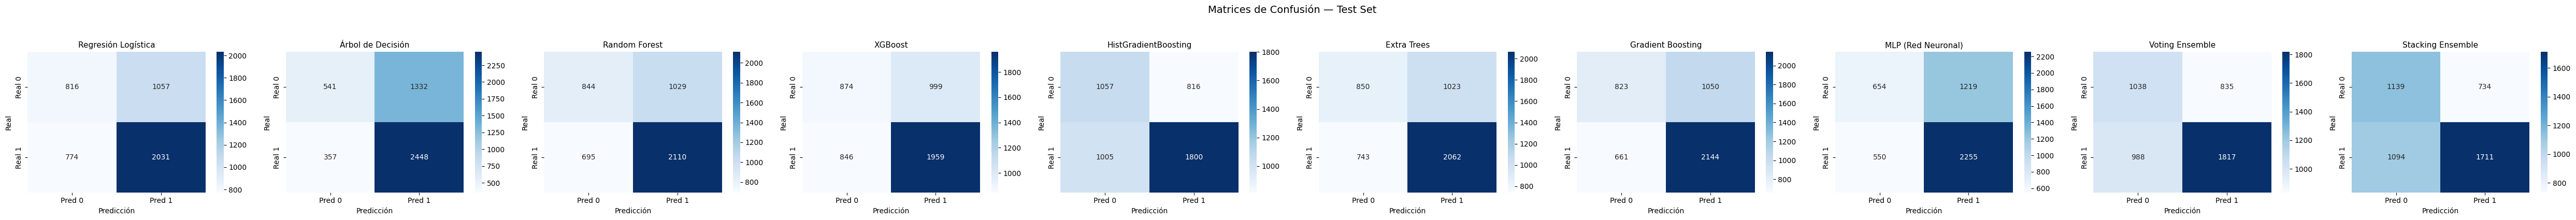


Versión: target_b_clinicamente_relevante


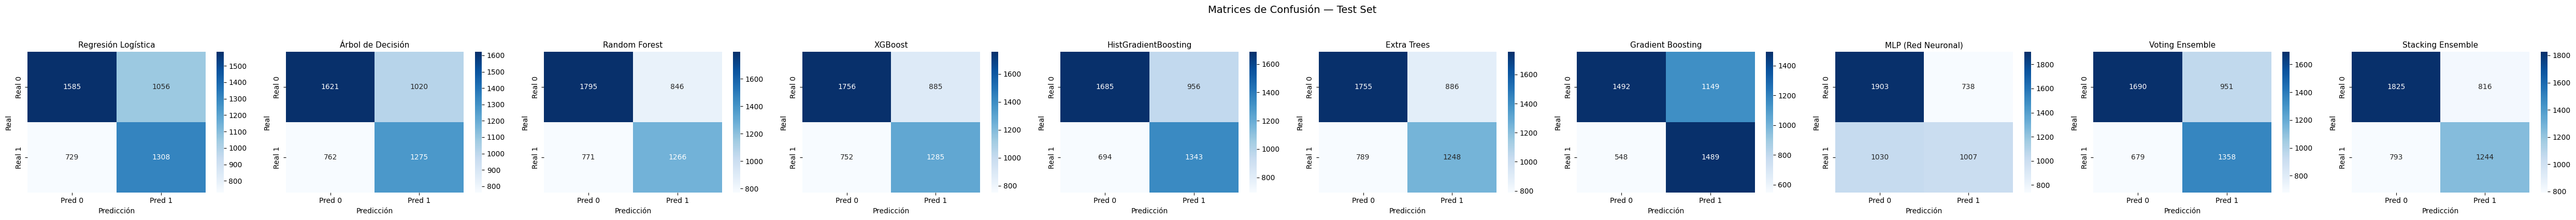


Versión: target_c_alta_severidad


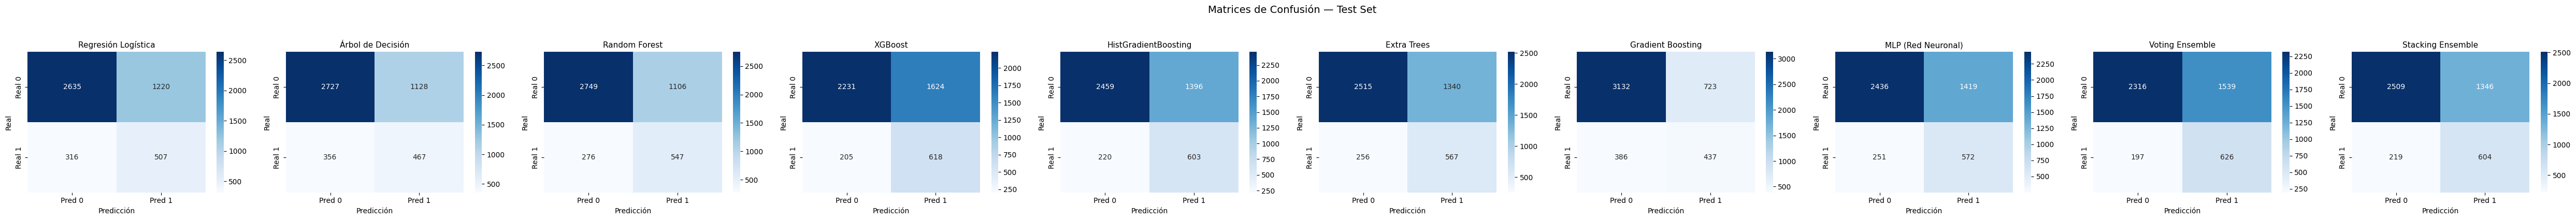

In [7]:
print("=" * 90)
print("MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_confusion_matrices(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../matrices_confusion_{version}.png",
    )

CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)

Versión: target_a_sensible


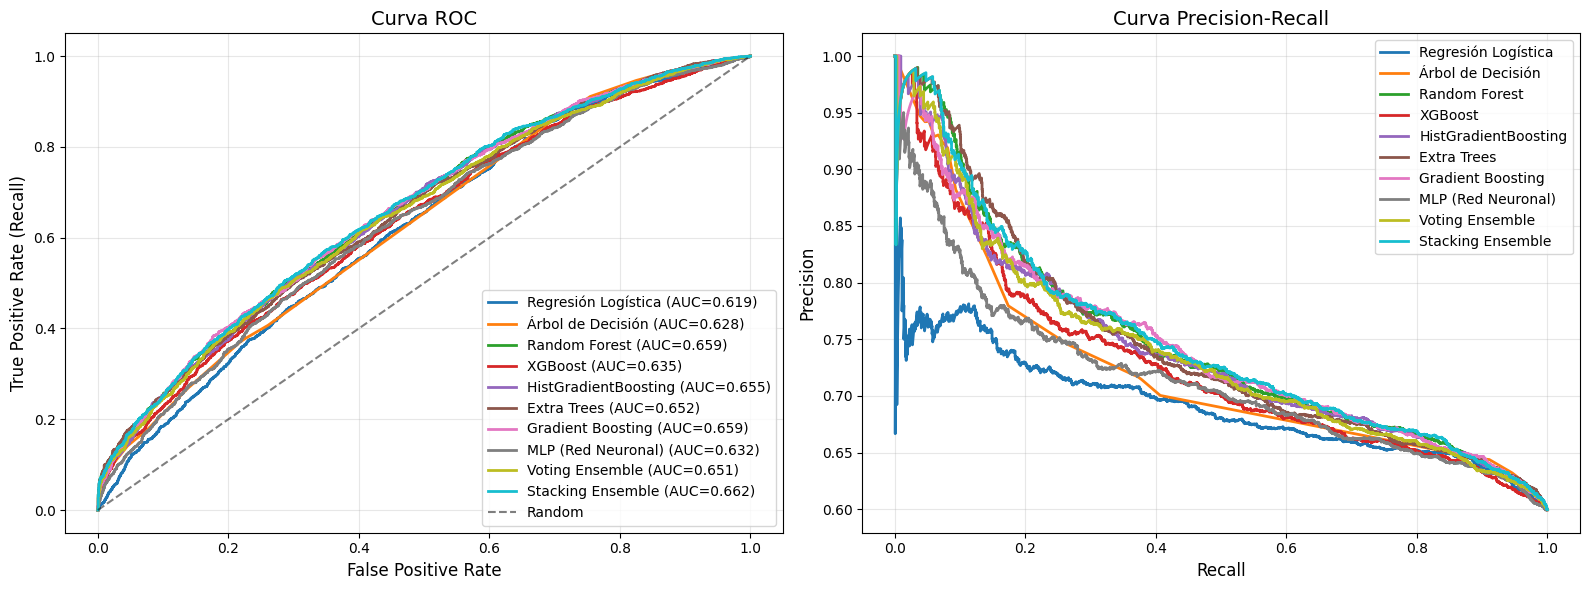


Versión: target_b_clinicamente_relevante


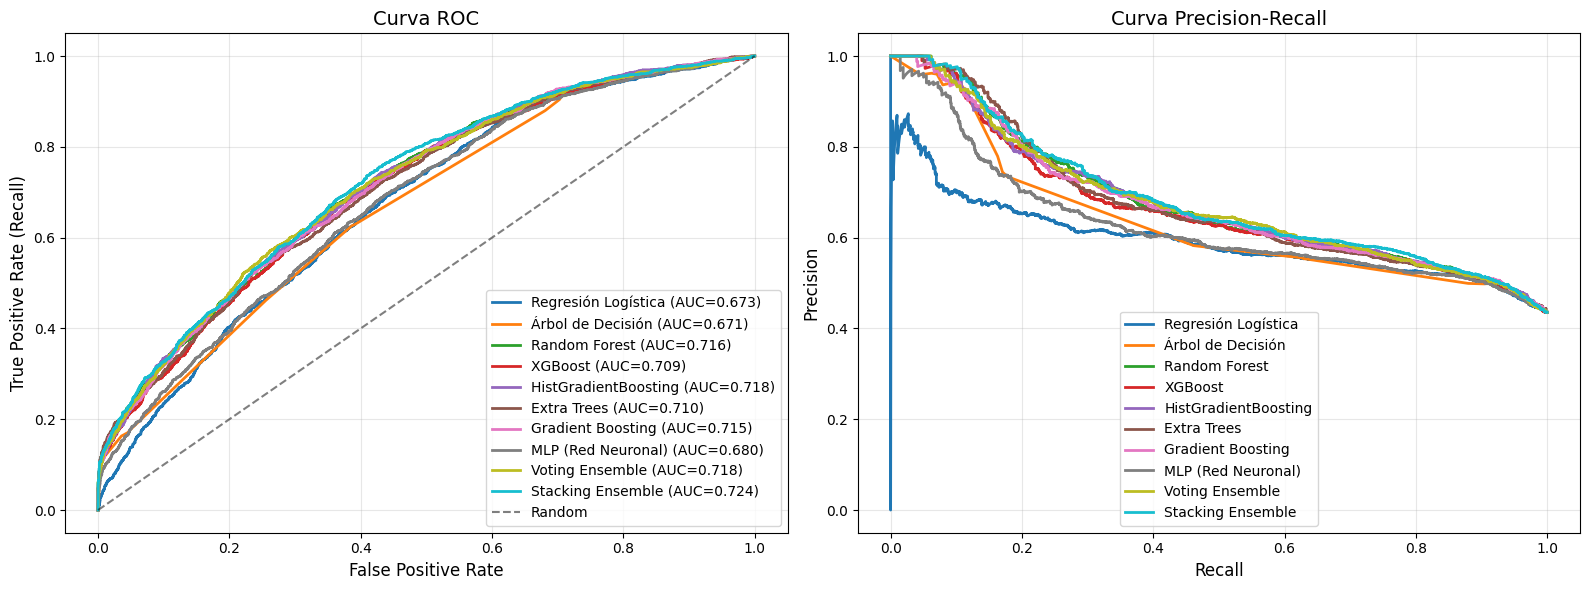


Versión: target_c_alta_severidad


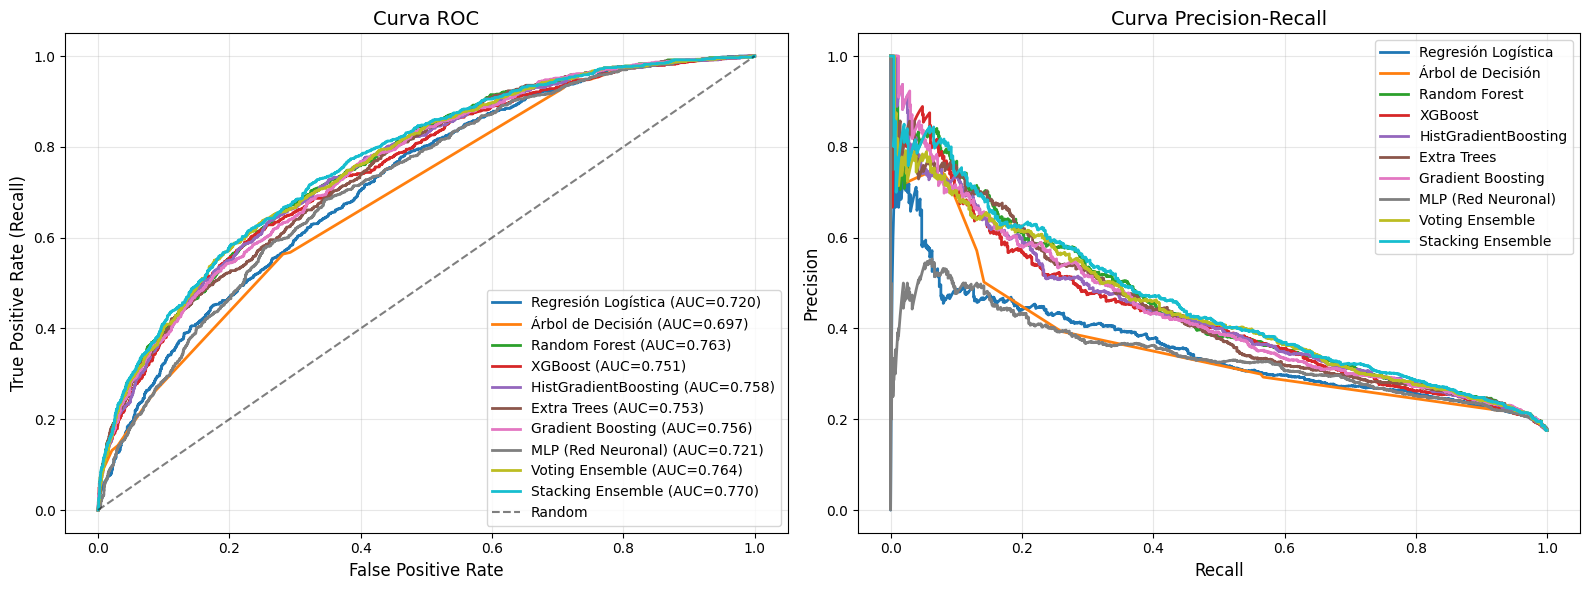

In [8]:
print("=" * 90)
print("CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_roc_pr_curves(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../curvas_roc_pr_{version}.png",
    )

## 6. Comparación Multi-Versión (Baseline + Balanceo de Clases)

In [9]:
summary_by_version = (
    df_results.sort_values(["Version", "ROC-AUC", "F2", "Accuracy"], ascending=[True, False, False, False])
    .groupby("Version", as_index=False)
    .first()
)

summary_by_version[[
    "Version",
    "Model",
    "Balance_Mode",
    "N_Train", "N_Val", "N_Test",
    "Train_Pos_Rate_Original",
    "Val_Pos_Rate_Original",
    "Test_Pos_Rate_Original",
    "Train_Pos_Rate_Used",
    "Val_Pos_Rate_Used",
    "Test_Pos_Rate_Used",
    "F2_Validation_OptThreshold",
    "Accuracy", "Recall", "Precision", "F1", "F2", "ROC-AUC", "Threshold", "N_Features",
]]

,Version,Model,Balance_Mode,N_Train,N_Val,N_Test,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,F2_Validation_OptThreshold,Accuracy,Recall,Precision,F1,F2,ROC-AUC,Threshold,N_Features
0,target_a_sensible,Stacking Ensemble,train_only,13110,2339,4678,0.599572,0.599401,0.599615,0.5,0.599401,0.599615,0.653566,0.609235,0.609982,0.699796,0.651810,0.626052,0.661661,0.51,80
1,target_b_clinicamente_relevante,Stacking Ensemble,train_only,14258,2339,4678,0.435492,0.435656,0.435442,0.5,0.435656,0.435442,0.652132,0.656050,0.610702,0.603883,0.607274,0.609326,0.723712,0.53,80
2,target_c_alta_severidad,Stacking Ensemble,train_only,5758,2339,4678,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.603222,0.665455,0.733900,0.309744,0.435629,0.576116,0.769748,0.49,80


In [10]:
pivot_auc = df_results.pivot(index="Version", columns="Model", values="ROC-AUC")
pivot_f2 = df_results.pivot(index="Version", columns="Model", values="F2")
pivot_acc = df_results.pivot(index="Version", columns="Model", values="Accuracy")

print("ROC-AUC por versión/modelo")
display(pivot_auc)

print("F2 por versión/modelo")
display(pivot_f2)

print("Accuracy por versión/modelo")
display(pivot_acc)

ROC-AUC por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.651955,0.659411,0.655203,0.631578,0.658730,0.618938,0.661661,0.650551,0.635285,0.628125
target_b_clinicamente_relevante,0.709822,0.715020,0.718120,0.679998,0.716455,0.673123,0.723712,0.717907,0.709231,0.670861
target_c_alta_severidad,0.752594,0.756080,0.757570,0.720878,0.762929,0.720104,0.769748,0.763551,0.750513,0.697254


F2 por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.720727,0.743721,0.650477,0.767320,0.734731,0.709743,0.626052,0.654916,0.690859,0.816000
target_b_clinicamente_relevante,0.606886,0.690247,0.642768,0.508946,0.616959,0.622146,0.609326,0.649326,0.622698,0.610457
target_c_alta_severidad,0.545297,0.490791,0.569836,0.541359,0.553084,0.505081,0.576116,0.573575,0.558366,0.477798


Accuracy por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.622488,0.634245,0.610731,0.621847,0.631466,0.608593,0.609235,0.610304,0.605601,0.638948
target_b_clinicamente_relevante,0.641941,0.637238,0.647285,0.622061,0.654339,0.618427,0.656050,0.651560,0.650064,0.619068
target_c_alta_severidad,0.658829,0.762933,0.654553,0.643010,0.704575,0.671655,0.665455,0.628901,0.609021,0.682770


OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)


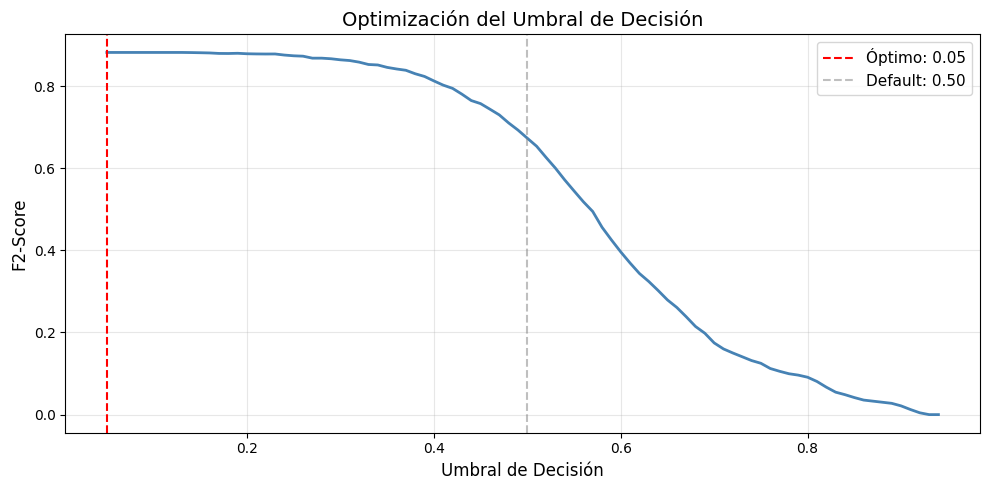

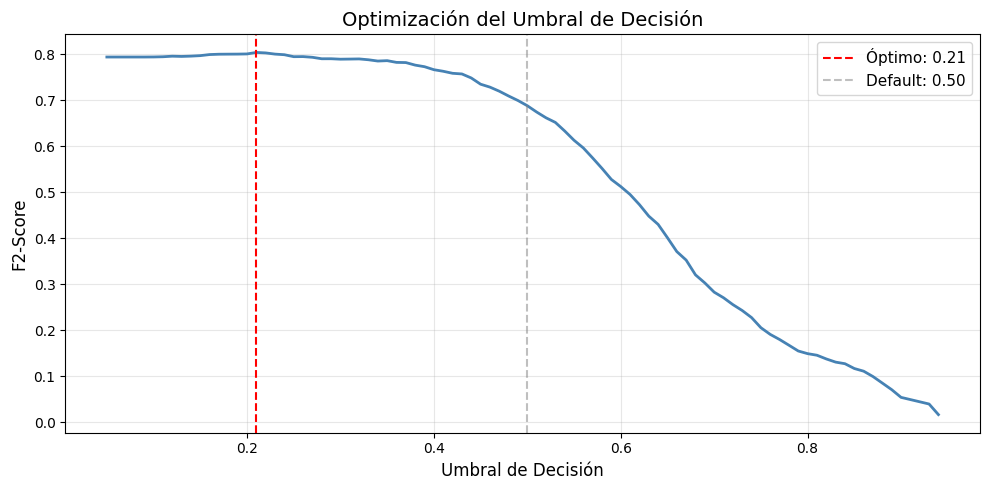

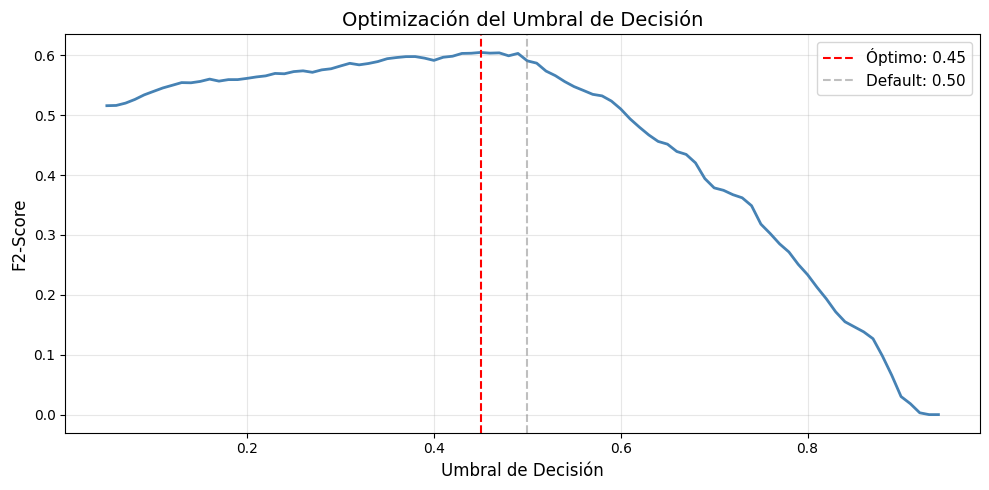

,Version,Model,Threshold_Optimo_F2_Validation,F2_Optimo_Validation
0,target_a_sensible,Stacking Ensemble,0.05,0.8821
1,target_b_clinicamente_relevante,Stacking Ensemble,0.21,0.8042
2,target_c_alta_severidad,Stacking Ensemble,0.45,0.6049


In [11]:
print("=" * 90)
print("OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)")
print("=" * 90)

y_val_by_version = modeling_artifacts["y_val_by_version"]
threshold_summary_rows = []

for version in sorted(predictions_by_version.keys()):
    version_rows = df_results[df_results["Version"] == version].sort_values(
        ["ROC-AUC", "F2", "Accuracy"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    if version_rows.empty:
        continue

    version_model = version_rows.iloc[0]["Model"]
    y_proba_val = predictions_by_version[version][version_model]["y_val_proba"]

    opt_thresh, opt_f2, thresholds, f2_scores = mod.find_optimal_threshold(
        y_val_by_version[version],
        y_proba_val,
        metric="f2",
    )

    viz.plot_threshold_optimization(
        thresholds,
        f2_scores,
        opt_thresh,
        save_path=f"../umbral_optimo_validation_{version}_{version_model.replace(' ', '_')}.png",
    )

    threshold_summary_rows.append(
        {
            "Version": version,
            "Model": version_model,
            "Threshold_Optimo_F2_Validation": round(float(opt_thresh), 4),
            "F2_Optimo_Validation": round(float(opt_f2), 4),
        }
    )

df_threshold_summary = pd.DataFrame(threshold_summary_rows).sort_values("Version").reset_index(drop=True)
df_threshold_summary

## 7. Explicabilidad por Versión (global y casos)

In [12]:
explainability_registry = modeling_artifacts["explainability_registry"]
global_expl = modeling_artifacts["explainability_global_by_version"]
case_expl = modeling_artifacts["explainability_cases_by_version"]

print("Registro de explicabilidad por versión:")
display(explainability_registry)

for version in sorted(global_expl.keys()):
    print(f"\n{'='*90}")
    print(f"EXPLICABILIDAD GLOBAL — Versión: {version}")
    print(f"{'='*90}")
    display(global_expl[version].head(20))

    print(f"\nCasos de auditoría clínica — Versión: {version}")
    display(case_expl[version].head(20))

print("\nArchivos exportados:")
for key, value in modeling_artifacts["output_paths"].items():
    print(f"- {key}: {value}")

Registro de explicabilidad por versión:


,Version,Best_Model_For_Explainability,Global_Explainability_Path,Case_Review_Path
0,target_a_sensible,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...
1,target_b_clinicamente_relevante,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...
2,target_c_alta_severidad,Stacking Ensemble,../features/modeling_versions/explainability_g...,../features/modeling_versions/explainability_c...



EXPLICABILIDAD GLOBAL — Versión: target_a_sensible


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.062714,permutation_importance
1,Tipo de anestesia propuesta_raquidea,0.017088,permutation_importance
2,Tipo de anestesia propuesta_peridural,0.008352,permutation_importance
3,Tensión Arterial Sistólica (mm/Hg),0.007134,permutation_importance
4,Examen_Hemoglobina(g/dl),0.007071,permutation_importance
5,score_proc_low_severity,0.004233,permutation_importance
6,Edad,0.003934,permutation_importance
7,score_proc_critical,0.003665,permutation_importance
8,Tipo de anestesia propuesta_general,0.003638,permutation_importance
9,anio,0.002521,permutation_importance



Casos de auditoría clínica — Versión: target_a_sensible


...


EXPLICABILIDAD GLOBAL — Versión: target_c_alta_severidad


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.076366,permutation_importance
1,Tipo de anestesia propuesta_peridural,0.018998,permutation_importance
2,Tipo de anestesia propuesta_raquidea,0.017789,permutation_importance
3,Examen_Hemoglobina(g/dl),0.013798,permutation_importance
4,Tipo de anestesia propuesta_local,0.009152,permutation_importance
5,Sexo_encoded,0.007695,permutation_importance
6,score_proc_medium_severity,0.007461,permutation_importance
7,Dx Preoperatorio Code_Z,0.007010,permutation_importance
8,Dx Preoperatorio Code_S,0.005953,permutation_importance
9,score_proc_high_severity,0.005114,permutation_importance



Casos de auditoría clínica — Versión: target_c_alta_severidad


,case_index,case_type,y_true,y_pred,y_proba,reason
0,22044,FN,1,0,0.489328,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
1,704,FN,1,0,0.487953,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
2,14172,FN,1,0,0.485402,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
3,22048,FN,1,0,0.485223,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
4,10163,FN,1,0,0.484829,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
5,10806,FN,1,0,0.483437,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
6,6696,FN,1,0,0.482523,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
7,7262,FN,1,0,0.482203,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
8,7947,FN,1,0,0.480790,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
9,1208,FN,1,0,0.479686,Tipo de anestesia propuesta_sedacion=0.0 | Tip...



Archivos exportados:
- results: ../features/modeling_versions/baseline_results_by_version.csv
- summary: ../features/modeling_versions/best_model_by_version.csv
- pivot_auc: ../features/modeling_versions/pivot_auc.csv
- pivot_f2: ../features/modeling_versions/pivot_f2.csv
- pivot_accuracy: ../features/modeling_versions/pivot_accuracy.csv
- explainability_registry: ../features/modeling_versions/explainability_registry.csv


In [13]:
top10_global = df_results.head(10).copy()
top10_global[["Version", "Model", "Accuracy", "F2", "ROC-AUC", "Recall", "Precision", "Threshold"]]

,Version,Model,Accuracy,F2,ROC-AUC,Recall,Precision,Threshold
0,target_c_alta_severidad,Stacking Ensemble,0.665455,0.576116,0.769748,0.733900,0.309744,0.49
1,target_c_alta_severidad,Voting Ensemble,0.628901,0.573575,0.763551,0.760632,0.289145,0.47
2,target_c_alta_severidad,Random Forest,0.704575,0.553084,0.762929,0.664642,0.330913,0.52
3,target_c_alta_severidad,HistGradientBoosting,0.654553,0.569836,0.757570,0.732685,0.301651,0.46
4,target_c_alta_severidad,Gradient Boosting,0.762933,0.490791,0.756080,0.530984,0.376724,0.57
5,target_c_alta_severidad,Extra Trees,0.658829,0.545297,0.752594,0.688943,0.297326,0.50
6,target_c_alta_severidad,XGBoost,0.609021,0.558366,0.750513,0.750911,0.275647,0.40
7,target_b_clinicamente_relevante,Stacking Ensemble,0.656050,0.609326,0.723712,0.610702,0.603883,0.53
8,target_c_alta_severidad,MLP (Red Neuronal),0.643010,0.541359,0.720878,0.695018,0.287293,0.42
9,target_c_alta_severidad,Regresión Logística,0.671655,0.505081,0.720104,0.616039,0.293573,0.53


## 8. Experimentos de entrenamiento (tuning + combinaciones)

Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes): 0
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Optimizing hyperparameters for: XGBoost (Target: roc_auc)
Optimizing hyperparameters for: Random Forest (Target: roc_auc)
Optimizing hyperparameters for: HistGradientBoosting (Target: roc_auc)
Optimizing hyperparameters for: Regresión Logística (Target: roc_auc)
Sanitización de Features realizada:
   - Originales: 80
   - Mantenidas: 80
   - Eliminadas (constantes

,Version,Model,Feature_Subset,N_Features,Validation_ROC-AUC,Validation_F2,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Tuning_Best_CV_Score,Tuning_N_Trials
0,target_a_sensible,Random Forest,top_100pct,80,0.670875,0.657409,0.659419,0.651561,0.612014,0.642781,0.689220,0.50,0.666655,15
1,target_b_clinicamente_relevante,XGBoost,top_100pct,80,0.737741,0.644520,0.720549,0.619883,0.656905,0.624448,0.602273,0.52,0.714953,15
2,target_c_alta_severidad,XGBoost,top_100pct,80,0.754345,0.561471,0.760233,0.557823,0.673365,0.697448,0.309768,0.50,0.748967,15


Top 20 experimentos de tuning:


,Version,Model,Feature_Subset,N_Features,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Validation_ROC-AUC,Validation_F2,Tuning_Best_CV_Score,Best_Params
0,target_c_alta_severidad,XGBoost,top_100pct,80,0.760233,0.557823,0.673365,0.697448,0.309768,0.50,0.754345,0.561471,0.748967,"{""max_depth"": 6, ""learning_rate"": 0.0115481393..."
1,target_c_alta_severidad,Random Forest,top_100pct,80,0.754318,0.543203,0.669944,0.676792,0.303542,0.51,0.752864,0.552112,0.746654,"{""n_estimators"": 1000, ""max_depth"": 27, ""min_s..."
2,target_c_alta_severidad,XGBoost,top_75pct,60,0.752553,0.566308,0.605173,0.767922,0.276224,0.46,0.744161,0.570560,0.747466,"{""max_depth"": 10, ""learning_rate"": 0.014054512..."
3,target_c_alta_severidad,HistGradientBoosting,top_100pct,80,0.752240,0.555138,0.642582,0.718104,0.290990,0.48,0.745249,0.568352,0.745592,"{""max_iter"": 1000, ""max_depth"": 11, ""learning_..."
4,target_c_alta_severidad,Random Forest,top_75pct,60,0.751591,0.523937,0.705430,0.619684,0.323810,0.53,0.743555,0.526694,0.745128,"{""n_estimators"": 600, ""max_depth"": 25, ""min_sa..."
5,target_c_alta_severidad,HistGradientBoosting,top_75pct,60,0.750514,0.572217,0.631894,0.755772,0.290247,0.47,0.739691,0.560170,0.745932,"{""max_iter"": 300, ""max_depth"": 6, ""learning_ra..."
6,target_c_alta_severidad,XGBoost,top_50pct,40,0.750086,0.551823,0.659897,0.698663,0.299791,0.50,0.738627,0.536952,0.741624,"{""max_depth"": 9, ""learning_rate"": 0.0118823517..."
7,target_c_alta_severidad,Random Forest,top_50pct,40,0.748378,0.548430,0.656050,0.696233,0.296584,0.51,0.736947,0.538859,0.739957,"{""n_estimators"": 300, ""max_depth"": 20, ""min_sa..."
8,target_c_alta_severidad,HistGradientBoosting,top_50pct,40,0.742149,0.547792,0.631894,0.714459,0.283373,0.48,0.730851,0.539736,0.737880,"{""max_iter"": 400, ""max_depth"": 11, ""learning_r..."
9,target_c_alta_severidad,Regresión Logística,top_50pct,40,0.725616,0.509098,0.695169,0.605103,0.311445,0.53,0.721201,0.497827,0.714448,"{""C"": 0.21383323918476438}"


Comparación directa Baseline vs Tuning (mejor por versión):


,Version,Baseline_Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Real_Prevalence,Train_Prevalence_Used,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,Val_Pos_Rate_Used,Test_Pos_Rate_Used,Predicted_Positive_Rate_Val,Predicted_Positive_Rate_Test,Threshold_Restrict_Prevalence,Threshold_Min_Pos_Rate,Threshold_Max_Pos_Rate,Optimize_For,Baseline_Accuracy,Recall,Precision,F1,Baseline_F2,Baseline_ROC-AUC,PR-AUC,Balanced_Accuracy,Specificity,Brier,Predicted_Positive_Rate,FN_Rate,Threshold,Threshold_Objective_Metric,Threshold_Objective_Score,F2_Validation_OptThreshold,Tuned_Model,Tuned_Feature_Subset,Tuned_ROC-AUC,Tuned_F2,Tuned_Accuracy,Delta_ROC-AUC,Delta_F2,Delta_Accuracy
0,target_a_sensible,Stacking Ensemble,13110,2339,4678,80,train_only,0.599564,0.5,0.599572,0.599401,0.599615,0.5,0.599401,0.599615,0.539547,0.522659,False,None,None,balanced_accuracy,0.609235,0.609982,0.699796,0.651810,0.626052,0.661661,0.747049,0.609049,0.608115,0.229025,0.522659,0.390018,0.51,balanced_accuracy,0.626020,0.653566,Random Forest,top_100pct,0.659419,0.651561,0.612014,-0.002242,0.025509,0.002779
1,target_b_clinicamente_relevante,Stacking Ensemble,14258,2339,4678,80,train_only,0.435498,0.5,0.435492,0.435656,0.435442,0.5,0.435656,0.435442,0.453613,0.440359,False,None,None,balanced_accuracy,0.656050,0.610702,0.603883,0.607274,0.609326,0.723712,0.683485,0.650864,0.691026,0.210078,0.440359,0.389298,0.53,balanced_accuracy,0.680648,0.652132,XGBoost,top_100pct,0.720549,0.619883,0.656905,-0.003163,0.010557,0.000855
2,target_c_alta_severidad,Stacking Ensemble,5758,2339,4678,80,train_only,0.175867,0.5,0.175870,0.175716,0.175930,0.5,0.175716,0.175930,0.438221,0.416845,False,None,None,balanced_accuracy,0.665455,0.733900,0.309744,0.435629,0.576116,0.769748,0.456047,0.692372,0.650843,0.198330,0.416845,0.266100,0.49,balanced_accuracy,0.709414,0.603222,XGBoost,top_100pct,0.760233,0.557823,0.673365,-0.009515,-0.018293,0.007909


Comparación visual: top n modelos por métrica


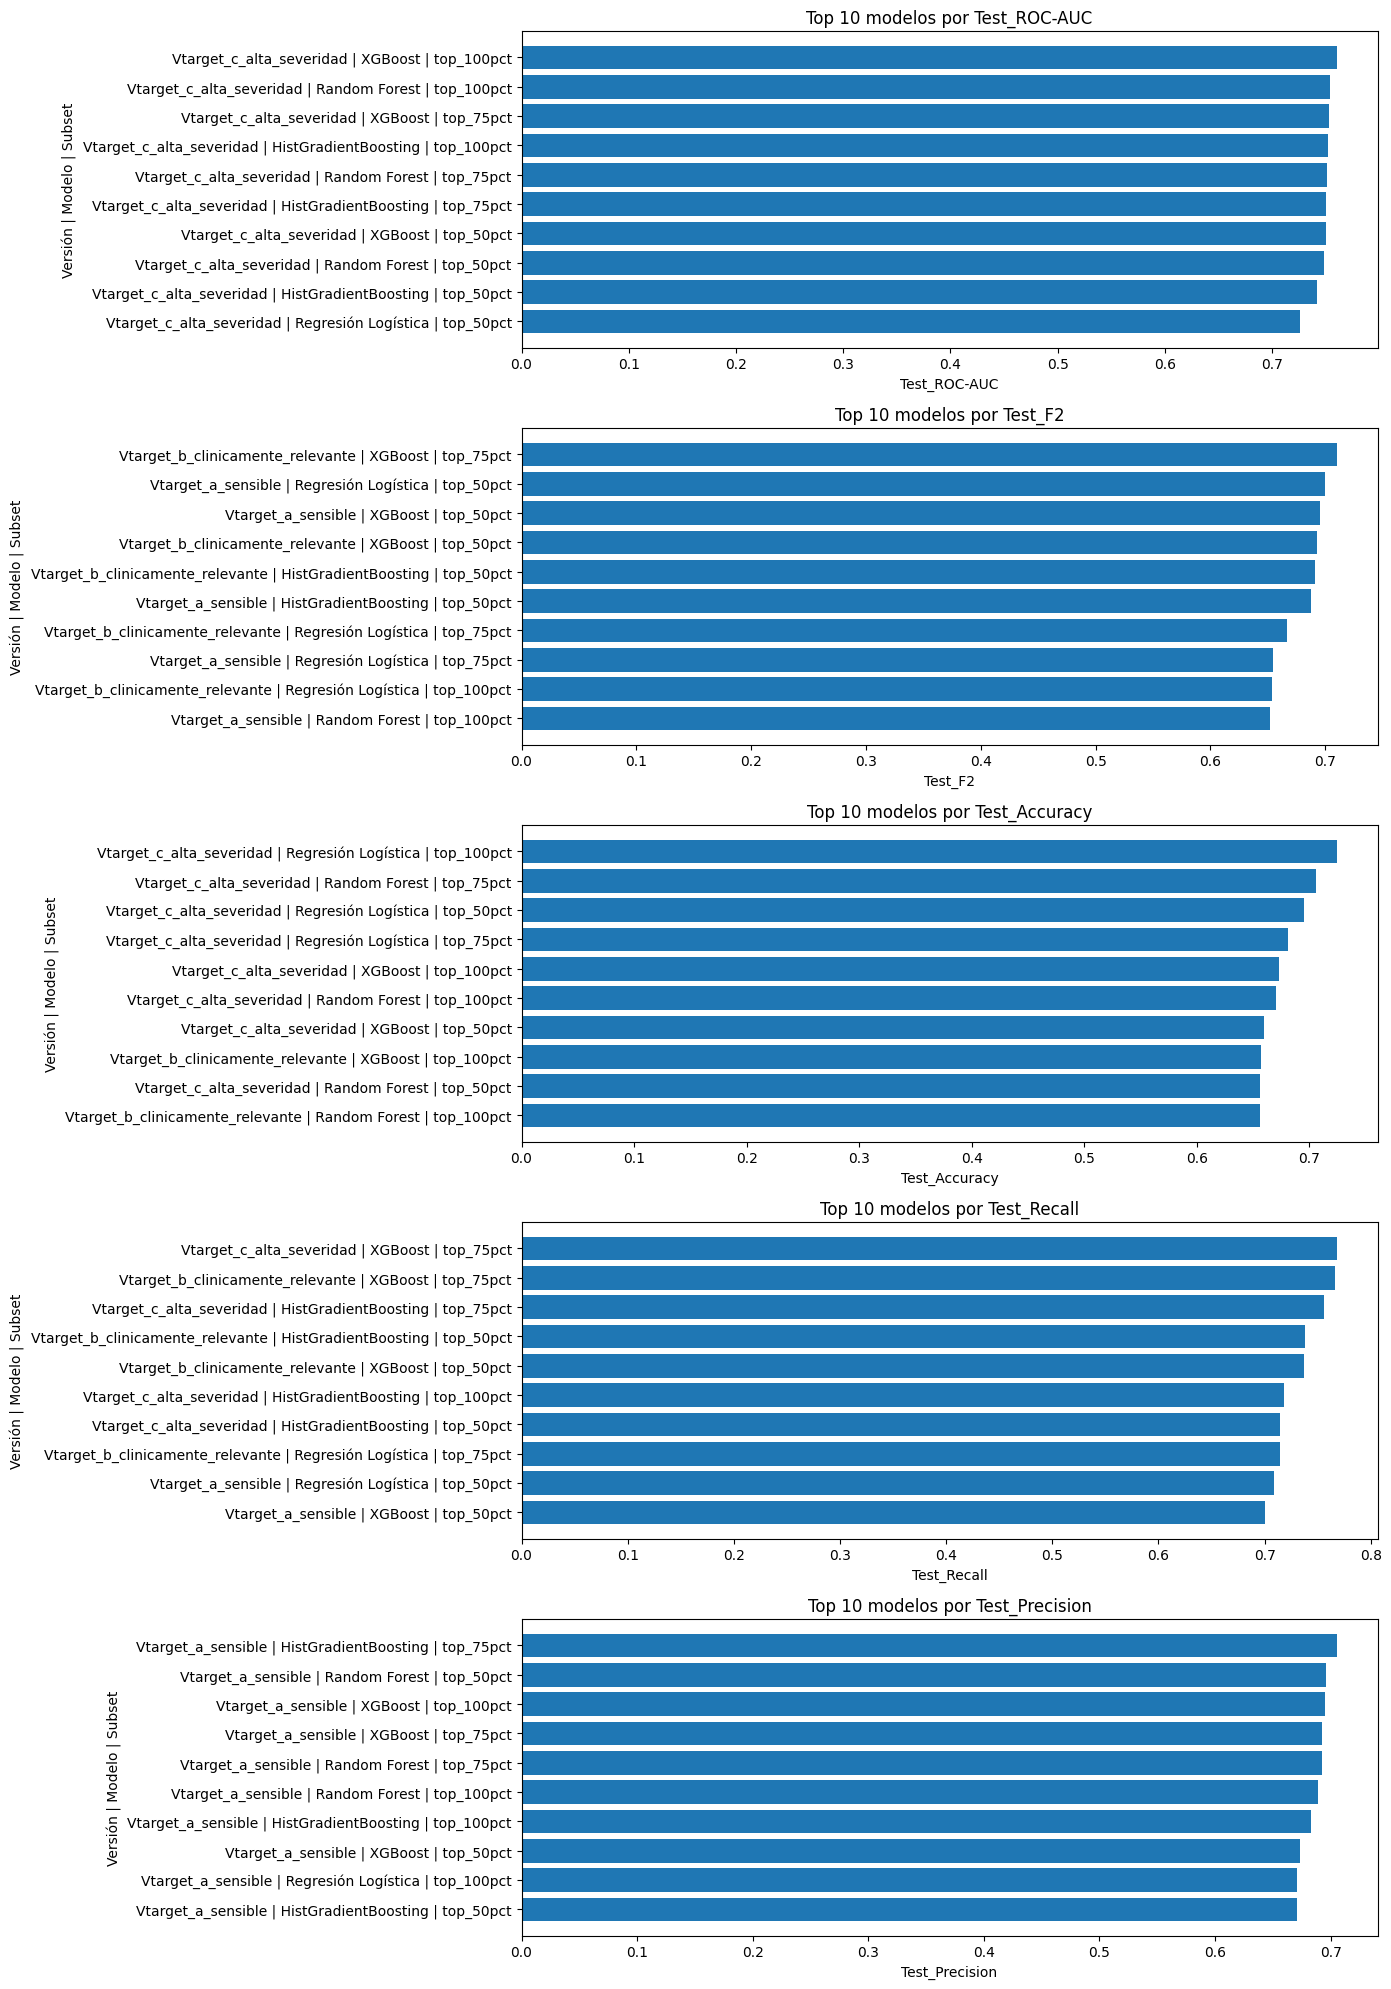

Archivos de tuning exportados:
- experiments: ../features/modeling_versions/hyperparameter_experiments.csv
- best_by_version: ../features/modeling_versions/hyperparameter_best_by_version.csv


In [14]:
hyper_artifacts = run_hyperparameter_experiments(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",
    val_size=0.2,
    test_size=0.2,
    threshold_metric="balanced_accuracy",
    threshold_prevalence_tolerance=0.5,
    tune_models=["XGBoost", "Random Forest", "HistGradientBoosting", "Regresión Logística"],
    optimize_metric="roc_auc",
    n_trials=15,
    feature_subset_fractions=(1.0, 0.75, 0.5),
)

df_hyper = hyper_artifacts["experiments"]
df_hyper_best = hyper_artifacts["best_by_version"]

print("Mejores resultados de tuning por versión:")
display(
    df_hyper_best[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Validation_ROC-AUC", "Validation_F2",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Tuning_Best_CV_Score", "Tuning_N_Trials",
    ]]
)

print("Top 20 experimentos de tuning:")
display(
    df_hyper[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Validation_ROC-AUC", "Validation_F2", "Tuning_Best_CV_Score", "Best_Params",
    ]].head(20)
)

print("Comparación directa Baseline vs Tuning (mejor por versión):")
baseline_best = (
    df_results.sort_values(["Version", "ROC-AUC", "F2"], ascending=[True, False, False])
    .groupby("Version", as_index=False)
    .first()
    .rename(columns={
        "Model": "Baseline_Model",
        "ROC-AUC": "Baseline_ROC-AUC",
        "F2": "Baseline_F2",
        "Accuracy": "Baseline_Accuracy",
    })
)

comparison = baseline_best.merge(
    df_hyper_best[["Version", "Model", "Feature_Subset", "Test_ROC-AUC", "Test_F2", "Test_Accuracy"]],
    on="Version",
    how="left",
).rename(columns={
    "Model": "Tuned_Model",
    "Feature_Subset": "Tuned_Feature_Subset",
    "Test_ROC-AUC": "Tuned_ROC-AUC",
    "Test_F2": "Tuned_F2",
    "Test_Accuracy": "Tuned_Accuracy",
})

comparison["Delta_ROC-AUC"] = comparison["Tuned_ROC-AUC"] - comparison["Baseline_ROC-AUC"]
comparison["Delta_F2"] = comparison["Tuned_F2"] - comparison["Baseline_F2"]
comparison["Delta_Accuracy"] = comparison["Tuned_Accuracy"] - comparison["Baseline_Accuracy"]

display(comparison.sort_values("Delta_ROC-AUC", ascending=False))

print("Comparación visual: top n modelos por métrica")
import matplotlib.pyplot as plt

n_top_models = 10
metric_cols = [
    "Test_ROC-AUC",
    "Test_F2",
    "Test_Accuracy",
    "Test_Recall",
    "Test_Precision",
]

df_plot = df_hyper.copy()
df_plot["Experiment_Label"] = (
    "V" + df_plot["Version"].astype(str)
    + " | " + df_plot["Model"].astype(str)
    + " | " + df_plot["Feature_Subset"].astype(str)
)

n_metrics = len(metric_cols)
fig, axes = plt.subplots(nrows=n_metrics, ncols=1, figsize=(14, 4 * n_metrics))

if n_metrics == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_cols):
    top_metric = (
        df_plot.sort_values(metric, ascending=False)
        .head(n_top_models)
        .sort_values(metric, ascending=True)
    )
    ax.barh(top_metric["Experiment_Label"], top_metric[metric])
    ax.set_title(f"Top {n_top_models} modelos por {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("Versión | Modelo | Subset")

plt.tight_layout()
plt.show()

print("Archivos de tuning exportados:")
for key, value in hyper_artifacts["output_paths"].items():
    print(f"- {key}: {value}")